# Data Reading and Initial Setup

In [73]:
import json
import pandas as pd

with open('dataCollection/data/modern.json') as f:
    modern_data = json.load(f)

with open('dataCollection/data/legacy.json') as f:
    legacy_data = json.load(f)

def build_table(videos):
    return pd.DataFrame([{
        'Title': v['title'],
        'Channel': v['channelTitle'],
        'Upload Year': pd.to_datetime(v['publishedAt']).year,
        'Comment Count': len(v['comments'])
    } for v in videos]).sort_values('Upload Year').reset_index(drop=True)

modern_df = build_table(modern_data['videos'])
legacy_df = build_table(legacy_data['videos'])

print("Modern")
display(modern_df)

print("Legacy")
display(legacy_df)


Modern


,Title,Channel,Upload Year,Comment Count
0,Meeting the Donbas Battalion: Russian Roulette in Ukraine (Dispatch 39),VICE News,2014,1000
1,Russia's Little Green Men Enter Ukraine: Russian Roulette in Ukraine,VICE News,2014,1000
2,Russia-Ukraine standoff in Kerch Strait,CaspianReport,2018,285
3,"""NovoRossiya"": Putin's Plan to Take Back Ukraine - TLDR News",TLDR News EU,2021,1000
4,Ukraine and Russia preparing for a new war,CaspianReport,2021,1000
5,Russia vs Ukraine: Should the West Intervene? - TLDR News,TLDR News EU,2021,1000
6,Has Russia's Invasion Stalled Again: Ukraine Fights Back - TLDR News,TLDR News EU,2022,1000
7,"After Kherson, Where Will Ukraine Go Next?",TLDR News EU,2022,1000
8,Invasion of Ukraine: A VICE News Tonight Special Report,VICE News,2022,1000
9,What a Russian assault on Ukraine would look like,CaspianReport,2022,1000


Legacy


,Title,Channel,Upload Year,Comment Count
0,Ukraine prepares for Russian invasion,Sky News Australia,2021,622
1,NATO pledges support for Ukraine amid escalating conflict with Russia,Sky News Australia,2021,434
2,NATO monitors Ukraine border for signs of Russian invasion | DW News,DW News,2021,1000
3,Russia-US talks on Ukraine: How real is threat of invasion? | DW News,DW News,2021,1000
4,Ukraine-Russia tensions - BBC News,BBC News,2021,1000
5,Russian troop build-up: View from Ukraine front line - BBC News,BBC News,2021,1000
6,Ukraine recaptures more territory in the south and north-east | Ukraine latest,DW News,2022,1000
7,Russia launches military attacks on Ukraine | DW News,DW News,2022,1000
8,Ukraine capital Kyiv endures Russian onslaught - BBC News,BBC News,2022,1000
9,On Ukraine’s border as tensions escalate with Russia - BBC Newsnight,BBC News,2022,1000


In [74]:
import json
import re
import nltk
from datetime import datetime, timezone
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException

stop_words = set(stopwords.words('english'))

def load_comments(filepath):
    """Load English comments from a YouTube JSON file."""
    comments = []
    skipped_non_english = 0
    skipped_empty = 0

    with open(filepath) as f:
        data = json.load(f)

    for video in data["videos"]:
        for comment in video.get("comments", []):
            text = comment.get("text", "").strip()
            if not text:
                skipped_empty += 1
                continue
            try:
                if detect(text) != 'en':
                    skipped_non_english += 1
                    continue
            except LangDetectException:
                skipped_non_english += 1
                continue

            comments.append({
                "author": comment["author"],
                "raw_text": text,
                "text": text.lower(),
                "publishedAt": comment["publishedAt"],
                "likeCount": comment["likeCount"],
                "videoTitle": video["title"],
                "channelTitle": video.get("channelTitle", ""),
            })

    print(f"{filepath}: {len(comments)} kept, {skipped_non_english} non-English, {skipped_empty} empty")
    return comments

legacy_comments = load_comments("dataCollection/data/legacy.json")
modern_comments = load_comments("dataCollection/data/modern.json")

dataCollection/data/legacy.json: 14564 kept, 2178 non-English, 2 empty
dataCollection/data/modern.json: 15181 kept, 2039 non-English, 0 empty


## Number of Unique Commenters

In [75]:
def commenter_stats(comments, label):
    authors = [c["author"] for c in comments]
    total = len(authors)
    unique = len(set(authors))
    print(f"{label}")
    print(f"  Total comments:    {total}")
    print(f"  Unique commenters: {unique}")
    return set(authors)

legacy_authors  = commenter_stats(legacy_comments,  "Legacy")
modern_authors  = commenter_stats(modern_comments,  "Modern")

all_comments = legacy_comments + modern_comments
all_authors  = legacy_authors | modern_authors
total        = len(all_comments)
unique       = len(all_authors)
print(f"Combined")
print(f"  Total comments:    {total}")
print(f"  Unique commenters: {unique}")
print(f"  Overlap (on both): {len(legacy_authors & modern_authors)}")

Legacy
  Total comments:    14564
  Unique commenters: 13213
Modern
  Total comments:    15181
  Unique commenters: 13935
Combined
  Total comments:    29745
  Unique commenters: 26702
  Overlap (on both): 446


## Timeline of comments

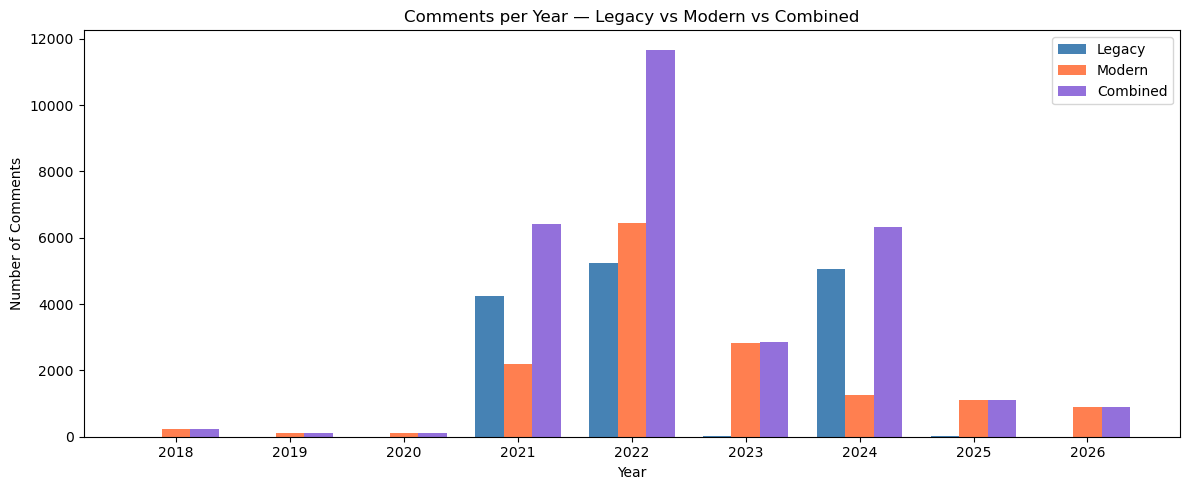

In [76]:
from collections import defaultdict
import matplotlib.pyplot as plt

def comments_by_year(comments):
    counts = defaultdict(int)
    for c in comments:
        year = datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00")).year
        counts[year] += 1
    return counts

legacy_by_year  = comments_by_year(legacy_comments)
modern_by_year  = comments_by_year(modern_comments)

all_years = sorted(set(legacy_by_year) | set(modern_by_year))

legacy_vals   = [legacy_by_year.get(y, 0)  for y in all_years]
modern_vals   = [modern_by_year.get(y, 0)  for y in all_years]
combined_vals = [l + m for l, m in zip(legacy_vals, modern_vals)]

x = range(len(all_years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width for i in x], legacy_vals,   width=width, label="Legacy",   color="steelblue")
ax.bar([i          for i in x], modern_vals,   width=width, label="Modern",   color="coral")
ax.bar([i + width  for i in x], combined_vals, width=width, label="Combined", color="mediumpurple")

ax.set_xticks(list(x))
ax.set_xticklabels(all_years)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Comments")
ax.set_title("Comments per Year — Legacy vs Modern vs Combined")
ax.legend()
plt.tight_layout()
plt.show()

### Counting Top 50 Words Before Preprocessing

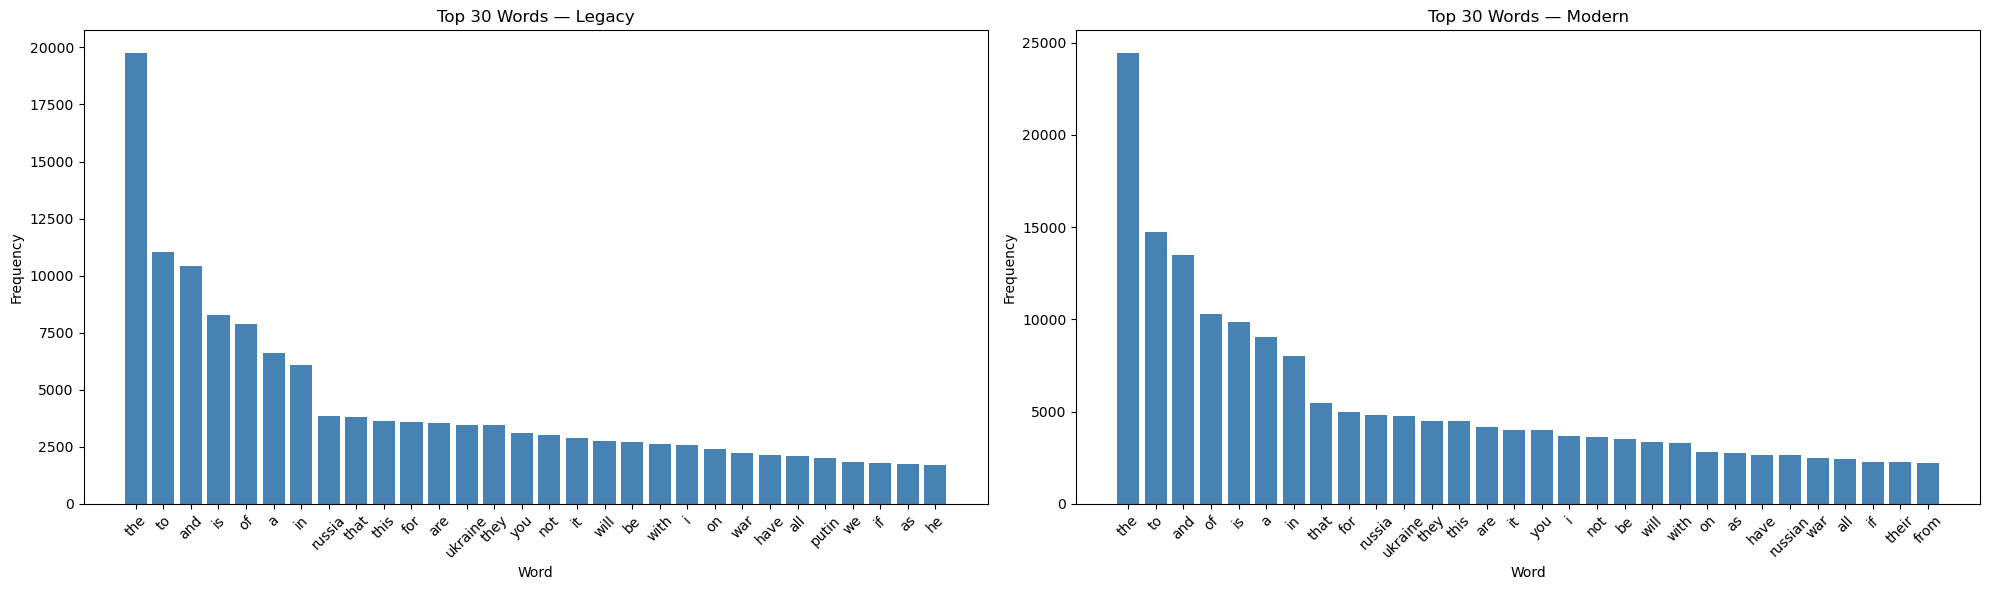

In [77]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Preprocessing
Preprocessing steps below include:
- Conversion to lowercase
- URL removal
- Abbreviations and acronyms replaced with natural language words
- Digits and fractions removed
- Tokenization into individual words
- Non-alphabetic tokens (punctuation, symbols) removed
- Stop words removed

In [78]:
def _preprocess_text(text):
    text = re.sub(r"https?://\S+", "", text)          # strip URLs
    text = re.sub(r"\b\d+([./]\d+)?\b", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t.strip() for t in tokens if t.strip().isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


def preprocess_comments(comments):
    """Tokenize and clean comments in-place; prints a summary."""
    for c in comments:
        c["tokens"] = _preprocess_text(c["text"])
        c["text"] = " ".join(c["tokens"])
    print(f"Preprocessed {len(comments)} comments")

preprocess_comments(legacy_comments)
preprocess_comments(modern_comments)

Preprocessed 14564 comments
Preprocessed 15181 comments


### Counting Top 50 Words After Preprocessing

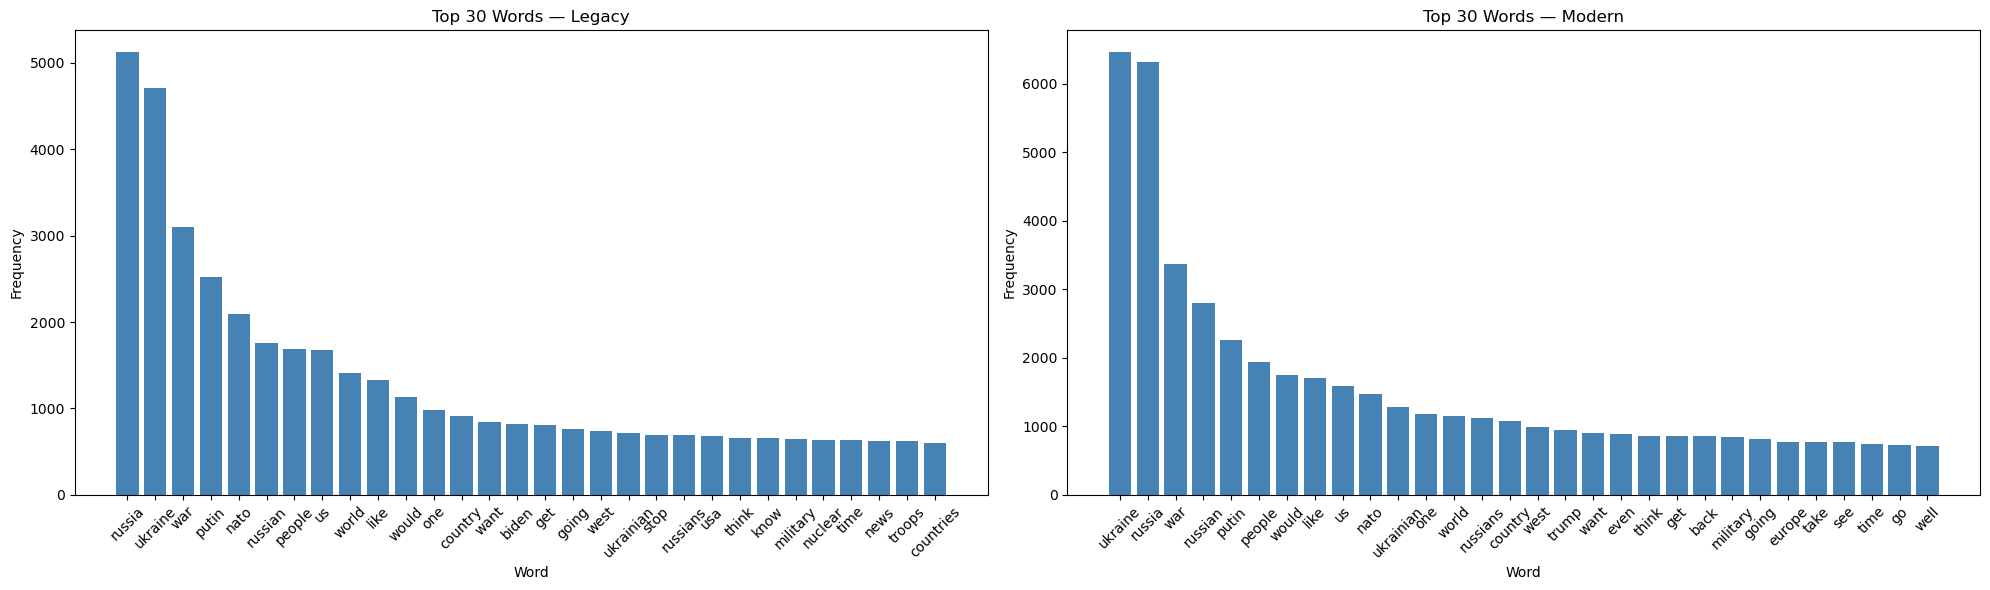

In [79]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [80]:
def run_sentiment(comments):
    sia = SentimentIntensityAnalyzer()
    vader_labels = Counter()

    for c in comments:
        scores = sia.polarity_scores(c["raw_text"])
        c["vaderScores"] = scores
        c["vaderCompound"] = scores["compound"]
        if scores["compound"] >= 0.05:
            c["vaderLabel"] = "positive"
        elif scores["compound"] <= -0.05:
            c["vaderLabel"] = "negative"
        else:
            c["vaderLabel"] = "neutral"
        vader_labels[c["vaderLabel"]] += 1

    total = len(comments)
    return {
        "total": total,
        "vader": {k: {"n": v, "pct": v / total * 100} for k, v in vader_labels.items()},
        "vader_mean": sum(c["vaderCompound"] for c in comments) / total,
    }

legacy_summary = run_sentiment(legacy_comments)
modern_summary = run_sentiment(modern_comments)

## Sentiment Distribution Charts

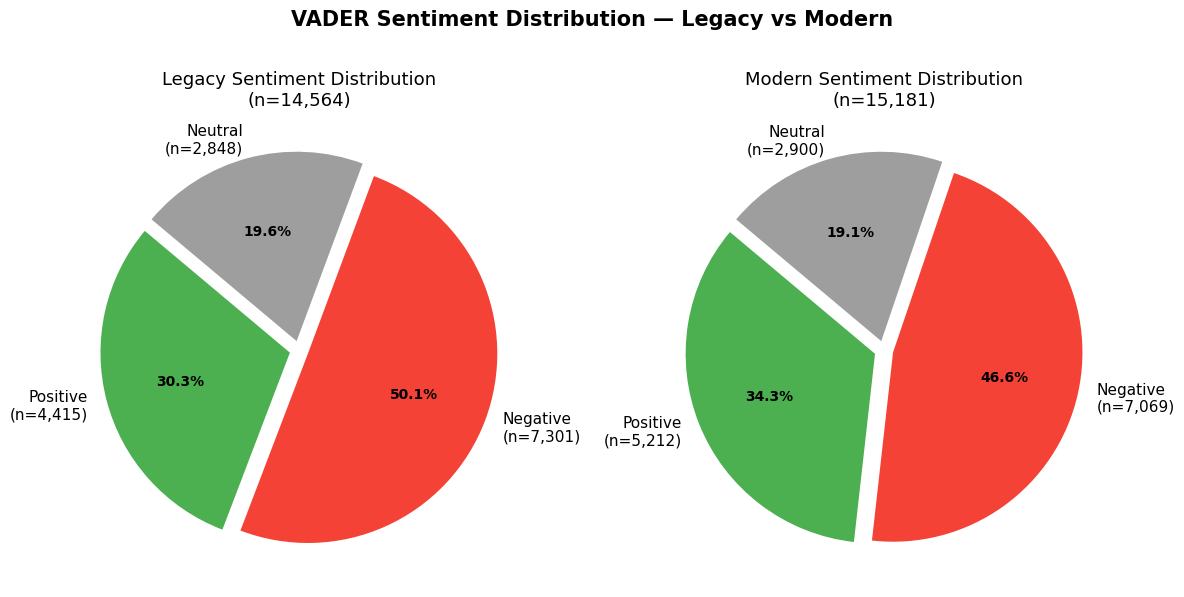

In [81]:
import matplotlib.pyplot as plt

def plot_sentiment_pies(legacy_summary, modern_summary):
    labels = ["positive", "negative", "neutral"]
    colors = {"positive": "#4CAF50", "negative": "#F44336", "neutral": "#9E9E9E"}
    explode = (0.05, 0.05, 0.05)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, summary, title in [
        (axes[0], legacy_summary, "Legacy"),
        (axes[1], modern_summary, "Modern"),
    ]:
        sizes = [summary["vader"].get(l, {"pct": 0})["pct"] for l in labels]
        counts = [summary["vader"].get(l, {"n": 0})["n"] for l in labels]
        pie_colors = [colors[l] for l in labels]

        wedges, texts, autotexts = ax.pie(
            sizes,
            labels=[f"{l.capitalize()}\n(n={c:,})" for l, c in zip(labels, counts)],
            autopct="%1.1f%%",
            colors=pie_colors,
            explode=explode,
            startangle=140,
            textprops={"fontsize": 11},
        )
        for at in autotexts:
            at.set_fontsize(10)
            at.set_fontweight("bold")

        ax.set_title(f"{title} Sentiment Distribution\n(n={summary['total']:,})", fontsize=13)

    plt.suptitle("VADER Sentiment Distribution — Legacy vs Modern", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_sentiment_pies(legacy_summary, modern_summary)
#ADD MEAN COMPOUND SCORE

## Word Clouds

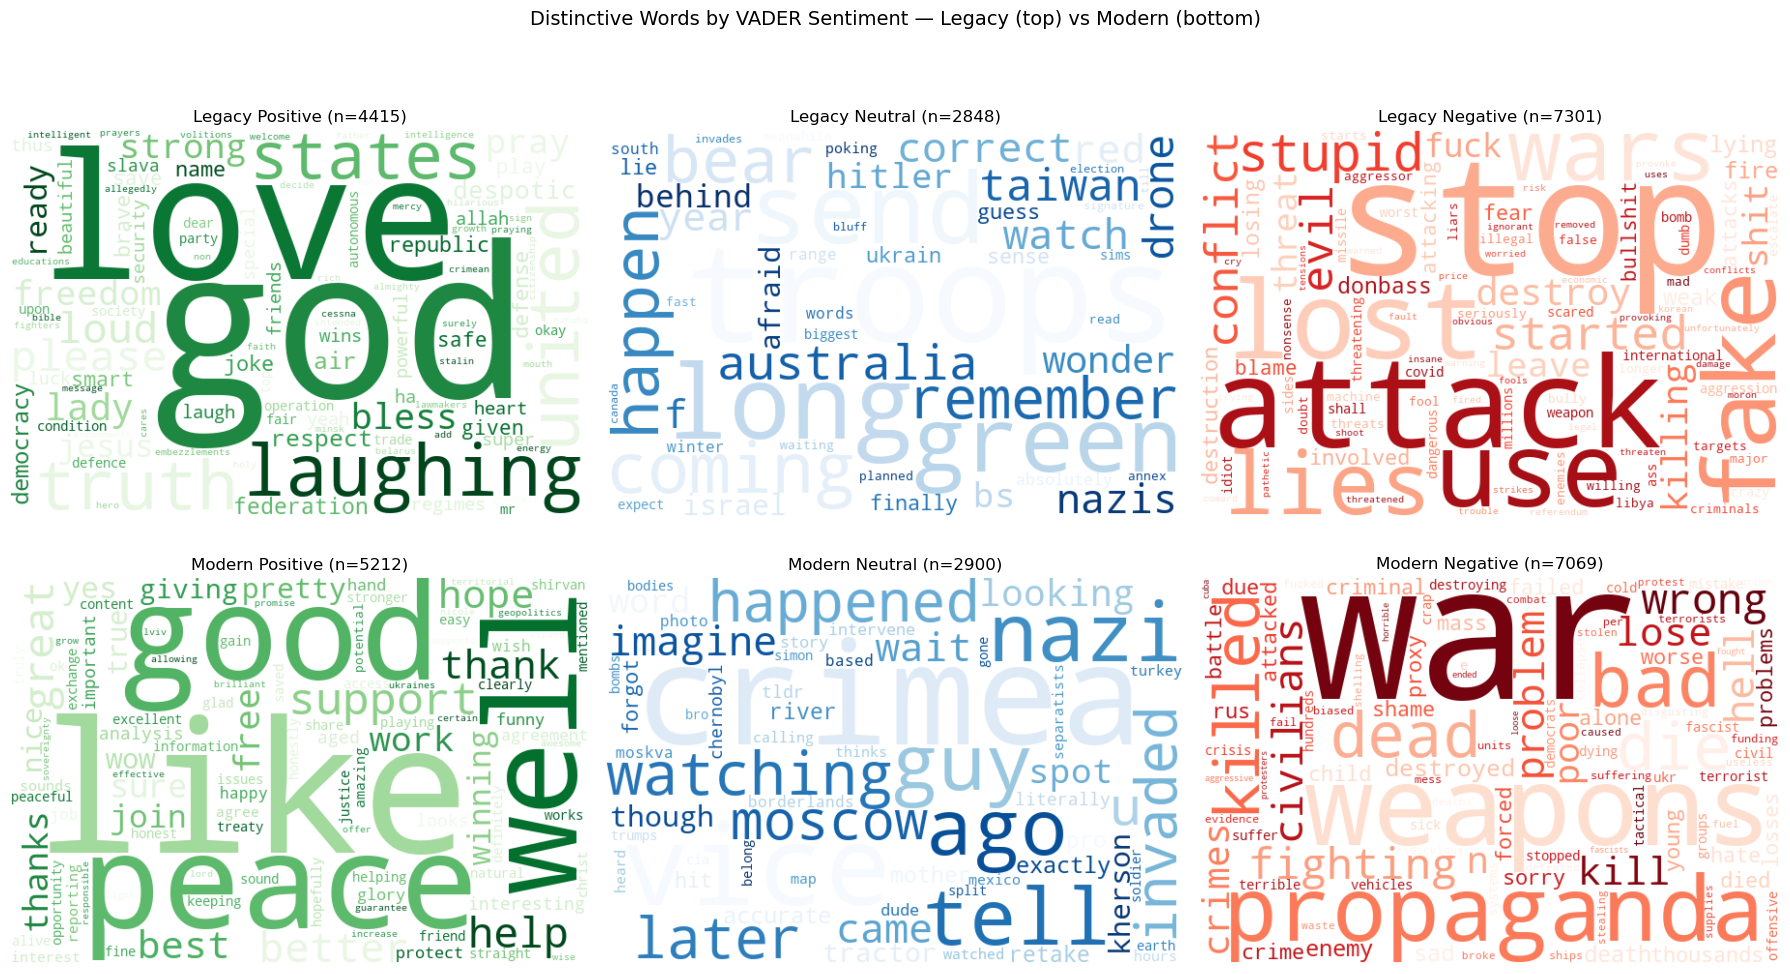

In [82]:
from wordcloud import WordCloud

def get_distinctive(comments_subset, all_comments, min_count=10):
    subset_ids = set(map(id, comments_subset))
    subset_freq = Counter(t for c in comments_subset for t in c['tokens'])
    rest_freq   = Counter(t for c in all_comments if id(c) not in subset_ids
                          for t in c['tokens'])
    total_sub  = sum(subset_freq.values()) or 1
    total_rest = sum(rest_freq.values()) or 1
    return {
        w: subset_freq[w]
        for w in subset_freq
        if subset_freq[w] >= min_count
        and subset_freq[w] / total_sub > 2 * (rest_freq.get(w, 0) / total_rest)
    }

def deduplicate_groups(freq_groups):
    result = {label: dict(freq) for label, freq in freq_groups.items()}
    for word in set(w for f in freq_groups.values() for w in f):
        best = max(freq_groups, key=lambda l: freq_groups[l].get(word, 0))
        for label in result:
            if label != best:
                result[label].pop(word, None)
    return result

# Legacy splits
l_pos = [c for c in legacy_comments if c['vaderCompound'] >= 0.05]
l_neu = [c for c in legacy_comments if -0.05 < c['vaderCompound'] < 0.05]
l_neg = [c for c in legacy_comments if c['vaderCompound'] <= -0.05]

# Modern splits
m_pos = [c for c in modern_comments if c['vaderCompound'] >= 0.05]
m_neu = [c for c in modern_comments if -0.05 < c['vaderCompound'] < 0.05]
m_neg = [c for c in modern_comments if c['vaderCompound'] <= -0.05]

groups = [
    (l_pos, legacy_comments, f'Legacy Positive (n={len(l_pos)})', 'Greens'),
    (l_neu, legacy_comments, f'Legacy Neutral (n={len(l_neu)})',  'Blues'),
    (l_neg, legacy_comments, f'Legacy Negative (n={len(l_neg)})', 'Reds'),
    (m_pos, modern_comments, f'Modern Positive (n={len(m_pos)})', 'Greens'),
    (m_neu, modern_comments, f'Modern Neutral (n={len(m_neu)})',  'Blues'),
    (m_neg, modern_comments, f'Modern Negative (n={len(m_neg)})', 'Reds'),
]

raw_freqs = {title: get_distinctive(subset, all_c) for subset, all_c, title, cmap in groups}
deduped   = deduplicate_groups(raw_freqs)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (subset, all_c, title, cmap) in zip(axes.flat, groups):
    freq = deduped[title]
    if freq:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=100)
        wc.generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Not enough\ndistinctive words',
                ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    ax.set_title(title, fontsize=12)

plt.suptitle('Distinctive Words by VADER Sentiment — Legacy (top) vs Modern (bottom)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Sentiment Over Time

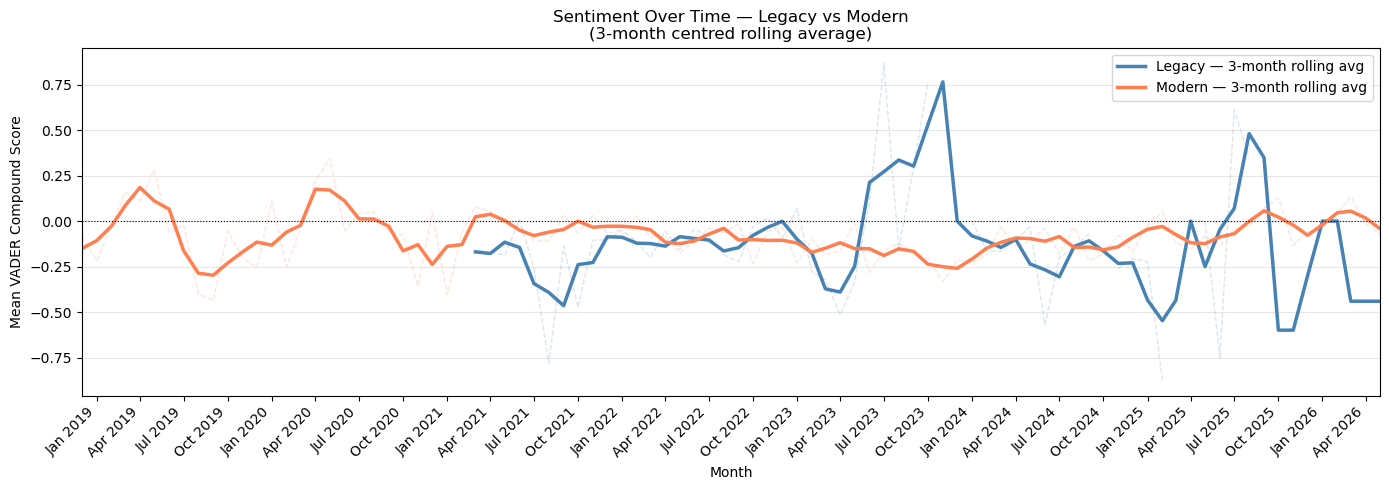

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Build monthly mean VADER compound score ---
def monthly_sentiment(comments, label):
    rows = [
        {
            "month": datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00"))
                             .replace(day=1, hour=0, minute=0, second=0, microsecond=0,
                                      tzinfo=None),
            "compound": c["vaderCompound"],
        }
        for c in comments
    ]
    df = pd.DataFrame(rows)
    return df.groupby("month")["compound"].mean().rename(label)

legacy_monthly = monthly_sentiment(legacy_comments, "Legacy")
modern_monthly = monthly_sentiment(modern_comments, "Modern")

# Align on the same date index, compute 3-month centred rolling average
combined = pd.concat([legacy_monthly, modern_monthly], axis=1).sort_index()
rolling  = combined.rolling(window=3, min_periods=1, center=True).mean()


fig, ax = plt.subplots(figsize=(14, 5))

# Rolling averages (bold)
ax.plot(rolling.index, rolling["Legacy"], color="steelblue", linewidth=2.5, label="Legacy — 3-month rolling avg")
ax.plot(rolling.index, rolling["Modern"], color="coral",     linewidth=2.5, label="Modern — 3-month rolling avg")

# Raw monthly means (faint, for context)
ax.plot(combined.index, combined["Legacy"], color="steelblue", alpha=0.2, linewidth=1, linestyle="--")
ax.plot(combined.index, combined["Modern"], color="coral",     alpha=0.2, linewidth=1, linestyle="--")

# Neutral baseline
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xlim(combined.index.min(), combined.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Month")
ax.set_ylabel("Mean VADER Compound Score")
ax.set_title("Sentiment Over Time — Legacy vs Modern\n(3-month centred rolling average)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()